In [1]:
#!pip install plotly !pip install numpy
#Import data_loader script !pip install pandas !pip install matplotlib !pip install seaborn
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["CURL_CA_BUNDLE"] = certifi.where()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from data_loader import DataLoader
#EDA libraries


plt.style.use('ggplot')
sns.set_theme()

In [3]:
#Ucitavanje train i test podataka
loader = DataLoader("Data/telco_churn_with_all_feedback.csv","Data/telco_churn_with_all_feedback.csv")
loader.load_data()
info=loader.get_basic_info()
print(info)
original_data,original_data1= loader.get_processed_data()
from sklearn.model_selection import train_test_split

train_processed, test_processed = train_test_split(
    original_data,
    test_size=0.2,
    random_state=42
)

Učitavanje train podataka...
Podaci učitani: (7043, 23)
Učitavanje test podataka...
Test podaci učitani: (7043, 23)
{'train_shape': (7043, 23), 'test_shape': (7043, 23), 'train_columns': ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'PromptInput', 'CustomerFeedback'], 'test_columns': ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'PromptInput', 'CustomerFeedback']}


## FEATURE ENGINEERING
<a id='featureeng'></a>

In [4]:
train_processed.info()
#customerID izbaciti - ne treba nam za predviđanje
#gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod - PREBACITI u kategoriju,ONE HOT encoding
#Provera NULL vrednosti
train_processed.isnull().sum()
test_processed.isnull().sum()

<class 'pandas.DataFrame'>
Index: 5634 entries, 2142 to 860
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  PaymentMe

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
PromptInput         0
CustomerFeedback    0
dtype: int64

In [5]:
#(train_processed == "").sum() --- SVE OK, nijedan atribut nema ""


# train_processed.apply(
#     lambda col: col.str.isspace().sum() if col.dtype == "object" else 0

#) #totalCharges ima 11 " "

fake_na = ["NA", "N/A", "na", "null", "NULL", "?", "nan", "NaN"]
for val in fake_na:
    print(val, (train_processed == val).sum().sum()) #SVE OK
(train_processed == "").sum() 


NA 0
N/A 0
na 0
null 0
NULL 0
? 0
nan 0
NaN 0


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
PromptInput         0
CustomerFeedback    0
dtype: int64

In [6]:
train_processed.apply(
     lambda col: col.str.isspace().sum() if col.dtype == "object" else 0
)
#Total charges necemo sredjivati, jer ce se kasnije atribut ukloniti
#provera jedinstvenih vrednosti
train_processed.nunique() #customerID brišemo

customerID          5634
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1490
TotalCharges        5281
Churn                  2
PromptInput         5498
CustomerFeedback    5634
dtype: int64

In [7]:
#Procenat korisnika koji su dali feedback, svaki korisnik je dao feedback
feedback_info = train_processed['CustomerFeedback'].notna()
train_processed['HasFeedback'] = feedback_info

feedback_info = test_processed['CustomerFeedback'].notna()
test_processed['HasFeedback'] = feedback_info
feedback_info.mean()

np.float64(1.0)

In [8]:
train_processed['feedback_length'] = train_processed['CustomerFeedback'].str.len()
test_processed['feedback_length'] = test_processed['CustomerFeedback'].str.len()

train_processed['feedback_length'].describe()
#Dužina korisničkih komentara je ujednačena, sa prosekom oko 460 karaktera i bez ekstremno kratkih ili praznih vrednosti

count    5634.000000
mean      460.163117
std        67.724553
min       277.000000
25%       414.000000
50%       454.000000
75%       499.000000
max       840.000000
Name: feedback_length, dtype: float64

In [9]:
test_processed['Churn'].value_counts(normalize=True)
#izuzetno nebalansiran skup podataka

Churn
No     0.740951
Yes    0.259049
Name: proportion, dtype: float64

In [10]:
#Analiza feedback-a korisnika koji su otišli i koji su se zadržali
pd.set_option('display.max_colwidth', None)
churned = train_processed[(train_processed['Churn'] == 'Yes')]
churned[['customerID', 'CustomerFeedback']].sample(3, random_state=1)

,customerID,CustomerFeedback
773,8627-EHGIP,"I have been a customer with this company for 44 months now, however, I have decided to churn. I have been on a one-year contract with a monthly charge of $53.95 for DSL internet service. I have always paid via mailed check. Overall, I have been satisfied with the service provided, but I have found a better deal elsewhere which is why I have decided to switch providers."
6348,8644-XLFBW,"I recently switched to this internet service provider for their fiber optic service and unfortunately, I have already decided to churn after only one month of service. While the internet speed was great and consistent, I found the monthly charges of $71.65 to be a bit steep for my budget. Additionally, I had issues with the electronic check payment method, as it was not as convenient as I had hoped. Overall, I was satisfied with the service itself, but the pricing and payment options did not meet my expectations."
645,5219-YIPTK,"I recently canceled my service after being with the company for 33 months on a month-to-month contract. The monthly charges of $104.4 for fiber optic internet were reasonable, and I appreciated the convenience of paying with electronic check. However, I ultimately decided to switch providers due to a better offer elsewhere. Overall, I had a positive experience with the service but chose to move on for financial reasons."


In [11]:
churned = train_processed[(train_processed['Churn'] == 'No')]
churned[['customerID', 'CustomerFeedback']].sample(3, random_state=1)

,customerID,CustomerFeedback
1271,6507-DTJZV,"I have been a customer with this company for 13 months now and have been satisfied with the DSL internet service provided. The monthly charges of $66.4 are reasonable for the service I am receiving. The automatic credit card payment method is convenient and ensures that I never miss a payment. Overall, I have had a positive experience with this company and have no plans to churn in the near future."
1925,1840-BIUOG,I have been a loyal customer with this internet provider for 20 months now and I have had a great experience so far. The monthly charges are reasonable at $68.7 and I appreciate being able to pay with electronic check. The DSL internet service has been reliable and I have not experienced any issues with connectivity. I am happy with the service and have no plans to switch providers.
2050,0487-RPVUM,"I have been a customer with this fiber optic internet service provider for over five years now, and I have been extremely satisfied with the service. The speed and reliability of the connection have been consistently excellent, and I have never experienced any downtime. \n\nThe automatic bank transfer payment method is convenient and hassle-free, and I appreciate not having to worry about remembering to pay my bill each month. The monthly charges of $99.4 are reasonable for the quality of service that I receive.\n\nOverall, I have no complaints and would highly recommend this provider to others looking for a reliable internet service."


In [12]:
#!pip install scipy
#Transformacija izlazne promenljive Churn i provera numerickih atributa
# Churn---Binary
train_processed['ChurnBinary'] = train_processed['Churn'].map({'No': 0, 'Yes': 1})
test_processed['ChurnBinary'] = test_processed['Churn'].map({'No': 0, 'Yes': 1})

# Numerički atributi u jednu listu
train_processed['TotalCharges'] = pd.to_numeric(train_processed['TotalCharges'], errors='coerce')
test_processed['TotalCharges'] = pd.to_numeric(test_processed['TotalCharges'], errors='coerce')

numeric_cols = train_processed.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('SeniorCitizen')

#Mann-Whitney test
from scipy import stats
#Razdvajanje izlaza
churn_0 = train_processed[train_processed['ChurnBinary'] == 0]
churn_1 = train_processed[train_processed['ChurnBinary'] == 1]

results = []

for col in numeric_cols:
    u_stat, p_value = stats.mannwhitneyu(
        churn_0[col].dropna(),
        churn_1[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        'Variable': col,
        'Test': 'Mann-Whitney U',
        'U_stat': u_stat,
        'p_value': p_value
    })

results_df = pd.DataFrame(results).sort_values('p_value')
results_df


,Variable,Test,U_stat,p_value
4,ChurnBinary,Mann-Whitney U,0.0,0.000000e+00
0,tenure,Mann-Whitney U,4553864.0,1.637168e-158
3,feedback_length,Mann-Whitney U,1868300.5,3.450432e-116
2,TotalCharges,Mann-Whitney U,3991218.5,1.166550e-61
1,MonthlyCharges,Mann-Whitney U,2323462.5,1.507892e-47


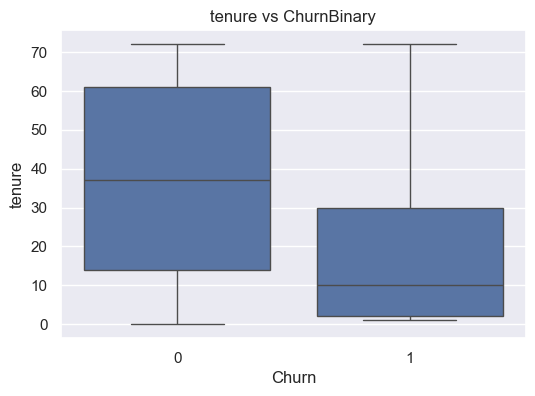

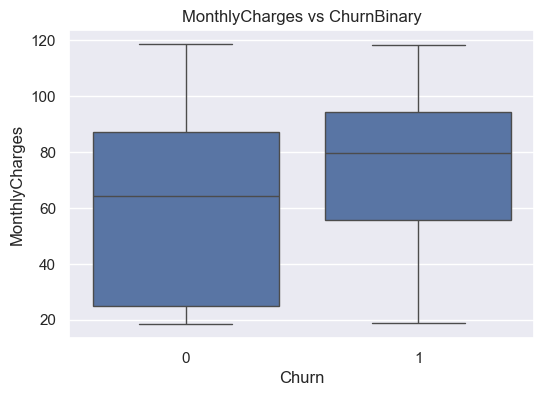

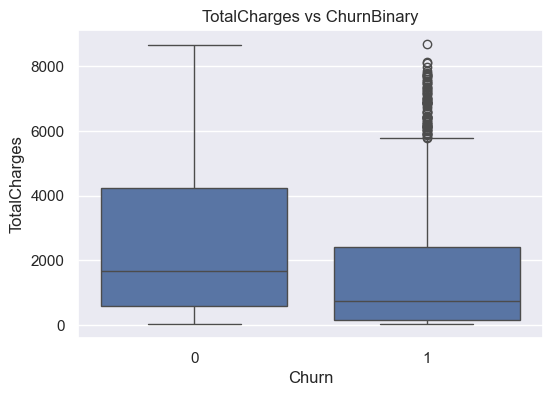

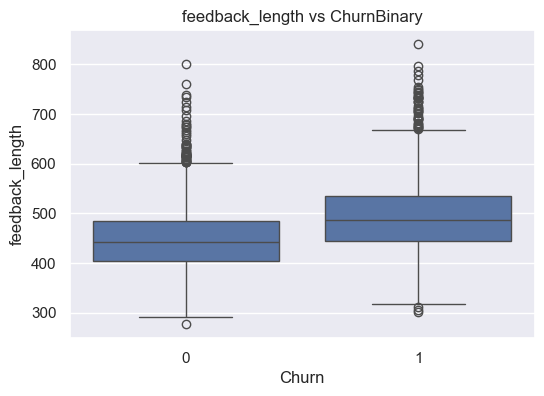

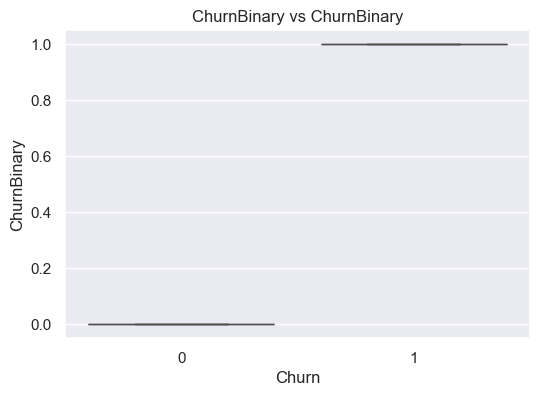

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='ChurnBinary', y=col, data=train_processed)
    plt.title(f"{col} vs ChurnBinary")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()


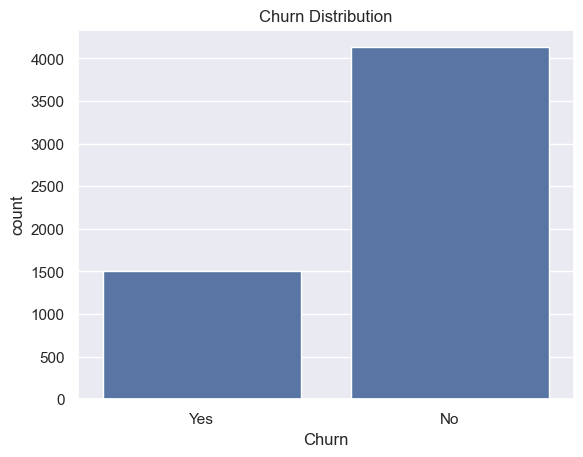

In [14]:
#Crtanje countplot-a koji prikazuje koliko ima korisnika sa Churn = "Yes" i "No", odnosno vizualizuje raspodelu odlazaka i ostanaka u datasetu.
sns.countplot(data=train_processed, x='Churn')
plt.title('Churn Distribution')
plt.show()

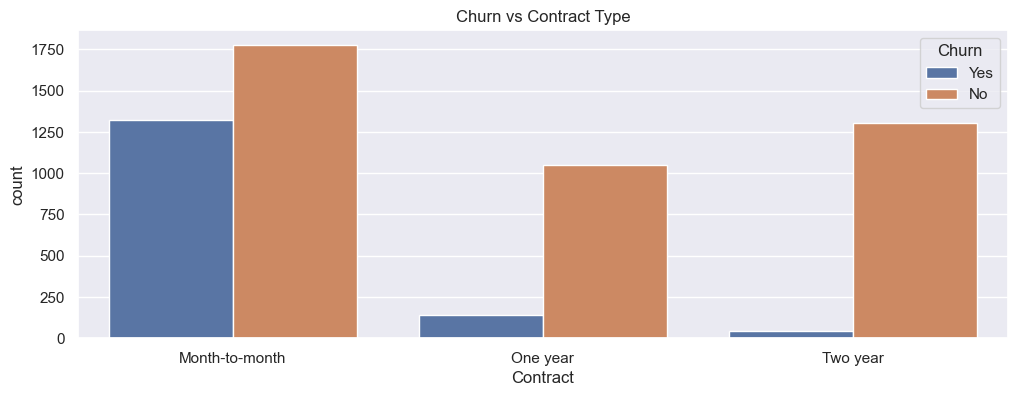

In [15]:
#provera korelacije kategorijskih atributa sa izlaznom promenljivom
# churn vs contract / internet
plt.figure(figsize=(12, 4))
sns.countplot(x='Contract', hue='Churn', data=train_processed)
plt.title('Churn vs Contract Type')
plt.show()

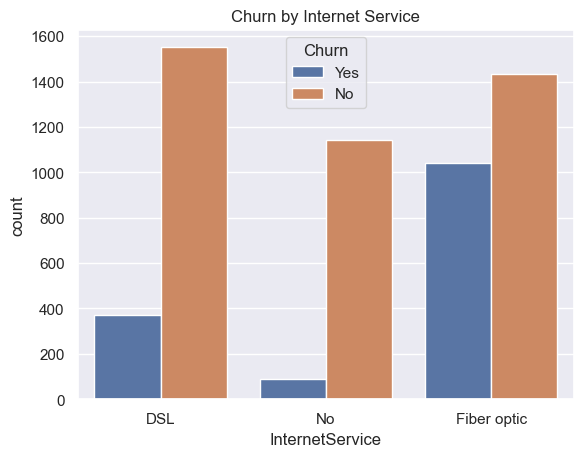

In [16]:
# Internet Service
sns.countplot(data=train_processed, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

Korisnici sa optičkim internetom imaju najviše stope churn-a, uprkos tome što koriste modernu uslugu.
Korisnici bez internet usluge retko odustaju — verovatno zbog nižih očekivanja ili jednostavnijih paketa.
Stopa churn-a kod DSL korisnika je umerena, što ukazuje na mešovito zadovoljstvo ili percepciju vrednosti usluge.

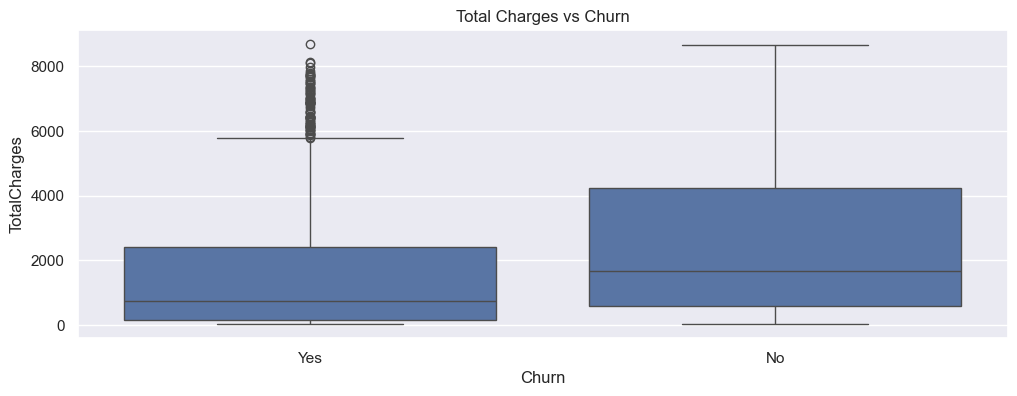

In [17]:
plt.figure(figsize=(12, 4))
sns.boxplot(x='Churn', y='TotalCharges', data=train_processed)
plt.title('Total Charges vs Churn')
plt.show()

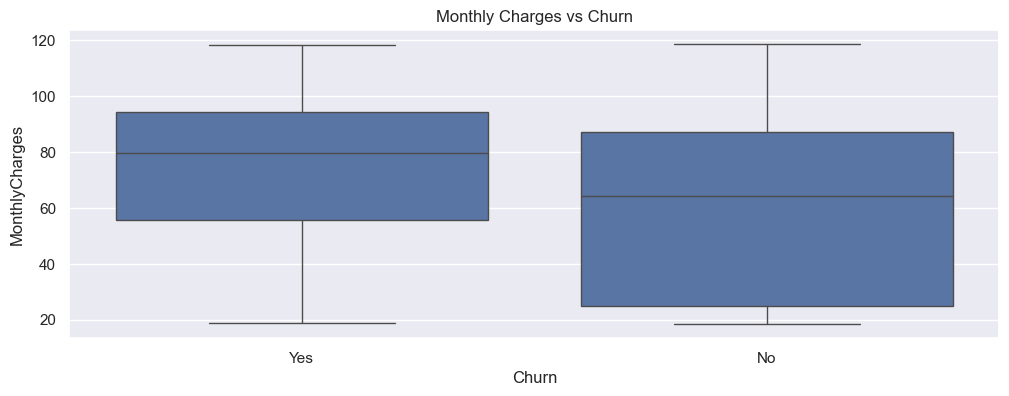

In [18]:
plt.figure(figsize=(12, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=train_processed)
plt.title('Monthly Charges vs Churn')
plt.show()

Korisnici koji odustanu uglavnom imaju nešto više prosečne mesečne troškove.
Cena može biti ključni faktor nezadovoljstva.
Ovo podržava pretpostavku da visoki mesečni troškovi mogu biti pokretač churn-a, posebno kod cenovno osetljivih korisnika.


In [19]:
# Korelacija izmedju dve numericke kolone (total i monthly charges)
corelation=train_processed['TotalCharges'].corr(train_processed['MonthlyCharges']).item()
print(corelation)

#korelisane,promene u jednoj su dosta povezane sa promenama u drugoj. izbaciti totalcharges


0.652182169798421


## Feedback exploration
<a id='Feedbackexploration'></a>

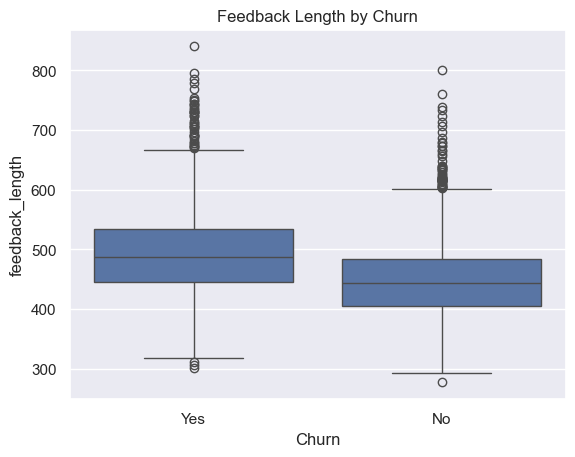

In [20]:
# Distribucija dužine feedback-a po Churn-u
sns.boxplot(data=train_processed, x='Churn', y='feedback_length')
plt.title('Feedback Length by Churn')
plt.show()

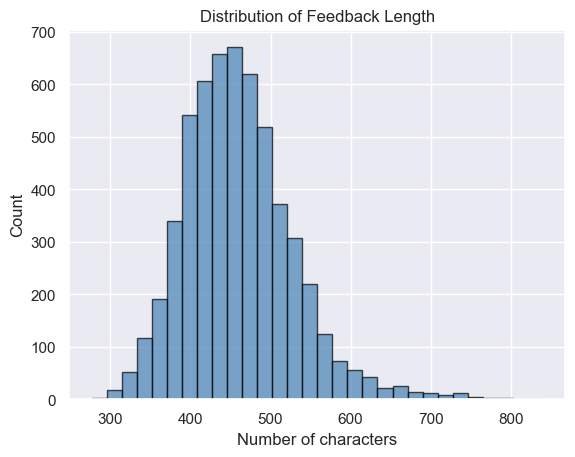

In [21]:
#feedback lenght
plt.hist(train_processed['feedback_length'],bins=30, alpha=0.7, label='Churn = No', color='steelblue', edgecolor='black')
plt.title("Distribution of Feedback Length")
plt.xlabel("Number of characters")
plt.ylabel("Count")
plt.show()

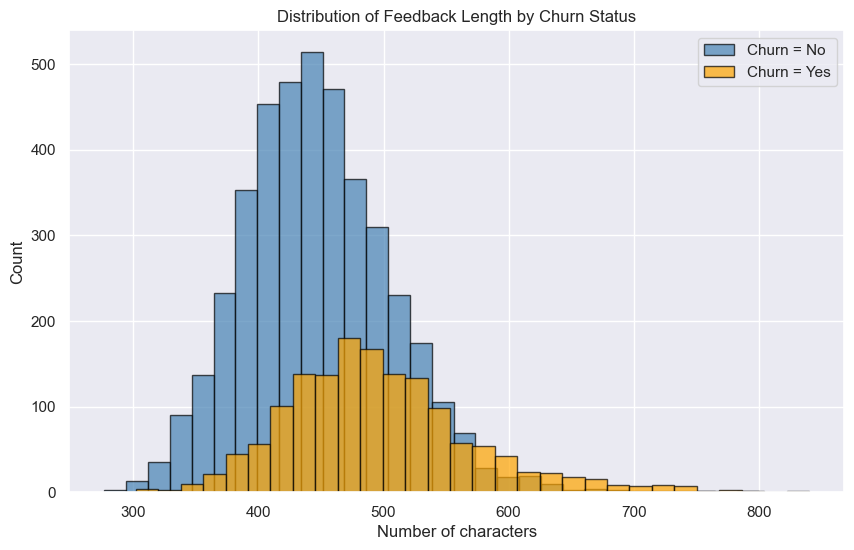

In [22]:
# Data separation
feedback_yes = train_processed[train_processed['Churn'] == 'Yes']['feedback_length']
feedback_no = train_processed[train_processed['Churn'] == 'No']['feedback_length']

# Histogram with two groups
plt.figure(figsize=(10, 6))
plt.hist(feedback_no, bins=30, alpha=0.7, label='Churn = No', color='steelblue', edgecolor='black')
plt.hist(feedback_yes, bins=30, alpha=0.7, label='Churn = Yes', color='orange', edgecolor='black')

plt.title("Distribution of Feedback Length by Churn Status")
plt.xlabel("Number of characters")
plt.ylabel("Count")
plt.legend()
plt.show()


Histogram pokazuje da korisnici koji su otišli (narandžasto) u proseku ostavljaju duže komentare od onih koji su ostali (plavo). Oba segmenta imaju sličan vrh (oko 400–450 karaktera), ali churn korisnici imaju nešto duži desni rep, što ukazuje na detaljnije ili emotivnije poruke — korisno za modelovanje i segmentaciju.

## Sentiment analiza - prosta
<a id='Simplesentimentanalysis'></a>

In [23]:

from textblob import TextBlob

# -1(negative) +1 (positive)
train_processed['sentiment'] = train_processed['CustomerFeedback'].apply(lambda x: TextBlob(x).sentiment.polarity)
train_processed[['CustomerFeedback', 'sentiment']].head()

test_processed['sentiment'] = test_processed['CustomerFeedback'].apply(lambda x: TextBlob(x).sentiment.polarity)
test_processed[['CustomerFeedback', 'sentiment']].head()



,CustomerFeedback,sentiment
185,"I recently switched to this DSL internet service provider and unfortunately, I experienced constant interruptions in my service. The speed was inconsistent and I had trouble staying connected while working from home. Additionally, I found the monthly charges to be quite high for the level of service I was receiving. I decided to cancel my subscription after only one month due to these issues. I hope the provider can improve their service quality in the future.",0.079375
2715,"I have been a customer with this company for 11 months now and I am very satisfied with their fiber optic internet service. The monthly charges of $89.2 are reasonable for the quality of service I am receiving. I appreciate the convenience of being able to pay through electronic check. Overall, I have had a positive experience with this company and have no intentions of churning.",0.179545
3825,"I have been a customer with this DSL internet service provider for 1 month now and I am very satisfied with the service. The monthly charges are reasonable at $62.8 and the internet connection has been reliable. I appreciate the option to pay via mailed check as it is convenient for me. Overall, I have had a positive experience with this provider and I have no plans to churn in the near future.",0.196212
1807,"I have been a loyal customer for over 4 and a half years and have been very satisfied with the service provided by this company. The automatic credit card payment option has made it convenient for me to pay my monthly charges without any hassle. Although I do not have internet service with this company, the low monthly charges of $18.8 for my other services have been very reasonable. I have had no issues with my contract type and have not experienced any churn. Overall, I am happy with the service and would recommend it to others.",0.150185
132,"I have been a customer with this DSL internet service provider for over five years now and I have been very satisfied with their service. The automatic bank transfer payment method is convenient and hassle-free. The monthly charges of $50.55 are reasonable for the quality of service provided. I have not experienced any issues with connectivity or speed, and I have no plans to switch to another provider. Overall, I would highly recommend this company to others looking for reliable internet service.",0.122000


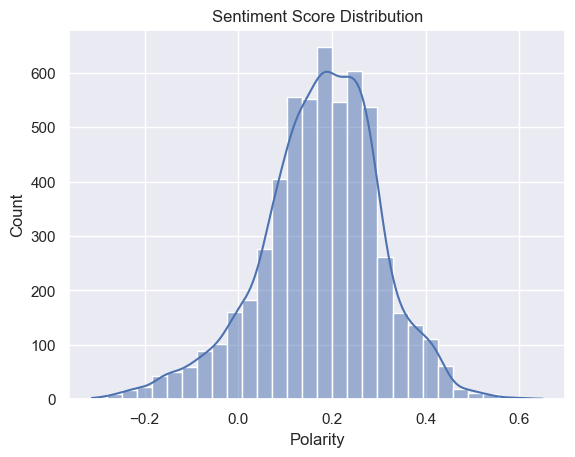

In [24]:
sns.histplot(train_processed['sentiment'], bins=30, kde=True)
plt.title("Sentiment Score Distribution")
plt.xlabel("Polarity")
plt.show()

Većina korisničkih komentara je blago pozitivna, bez ekstremno negativnog sentimenta.
Distribucija sentiment skorova je uglavnom oko neutralne do blago negativne polaritete, što sugeriše da su komentari više činjenični ili usmereni na pritužbe. Malo korisnika izražava snažno pozitivan ton — verovatno zato što se povratne informacije češće daju kada postoji neki problem. Ovo podržava ideju da analiza sentimenta može biti prediktivna za churn i korisna za segmentaciju korisnika prema emocionalnom tonu.

Ključni nalazi:
Skup podataka sadrži 7.043 zapisa o korisnicima, sa strukturiranim atributima i generisanim tekstualnim komentarima.
Stopa odlaska korisnika je oko 26%, uz prisutnu neravnotežu klasa, što je uobičajeno u realnim scenarijima.
Korisnici sa mesečnim ugovorima imaju znatno veću stopu churn-a, dok ugovori na 1–2 godine poboljšavaju zadržavanje.
Veće mesečne naknade i fiber optic internet su pozitivno povezani sa churn-om.
Korisnici koji su napustili uslugu pišu duže i izražajnije komentare, često naglašavajući nezadovoljstvo.
Analiza sentimenta pokazuje naginjanje ka neutralnom do negativnom tonu, posebno kod churnovanih korisnika.
Dužina komentara i sentiment imaju statistički značajne korelacije sa churn statusom.

In [25]:
train_processed = train_processed.drop('customerID', axis=1)
train_processed = train_processed.drop('HasFeedback', axis=1)
train_processed = train_processed.drop('TotalCharges', axis=1)
train_processed = train_processed.drop('Churn', axis=1)

#Ne nose nikakvu informaciju
train_processed = train_processed.drop('gender', axis=1)
train_processed = train_processed.drop('PromptInput', axis=1)


#test dataset
test_processed = test_processed.drop('customerID', axis=1)
test_processed = test_processed.drop('HasFeedback', axis=1)
test_processed = test_processed.drop('TotalCharges', axis=1)
test_processed = test_processed.drop('Churn', axis=1)

#Ne nose nikakvu informaciju
test_processed = test_processed.drop('gender', axis=1)
test_processed = test_processed.drop('PromptInput', axis=1)

In [26]:
for col in test_processed.columns:
    print(col, test_processed[col].dtype)



SeniorCitizen int64
Partner str
Dependents str
tenure int64
PhoneService str
MultipleLines str
InternetService str
OnlineSecurity str
OnlineBackup str
DeviceProtection str
TechSupport str
StreamingTV str
StreamingMovies str
Contract str
PaperlessBilling str
PaymentMethod str
MonthlyCharges float64
CustomerFeedback str
feedback_length int64
ChurnBinary int64
sentiment float64


In [27]:
categorical_cols = [
    "Partner","Dependents","PhoneService","MultipleLines",
    "InternetService","OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies","Contract",
    "PaperlessBilling","PaymentMethod"
]

train_encoded = pd.get_dummies(train_processed, 
                               columns=categorical_cols, 
                               drop_first=True)

test_encoded = pd.get_dummies(test_processed, 
                               columns=categorical_cols, 
                               drop_first=True)



## Skaliranje numerickih atributa
<a id='Simplesentimentanalysis'></a>

In [28]:
numeric_cols_clean = [col for col in numeric_cols if col not in ['ChurnBinary', 'TotalCharges']]
print(numeric_cols_clean)


['tenure', 'MonthlyCharges', 'feedback_length']


In [29]:
train_encoded[numeric_cols_clean].describe()


,tenure,MonthlyCharges,feedback_length
count,5634.000000,5634.000000,5634.000000
mean,32.332623,64.609523,460.163117
std,24.499668,30.152186,67.724553
min,0.000000,18.400000,277.000000
25%,9.000000,35.162500,414.000000
50%,29.000000,70.300000,454.000000
75%,55.000000,89.800000,499.000000
max,72.000000,118.650000,840.000000


In [30]:
#!pip install scikit-learn
from sklearn.preprocessing import StandardScaler

# Kreiramo scaler
scaler = StandardScaler()

# Kopiramo DataFrame da ne menjamo original
train_scaled = train_encoded.copy()

# Skaliramo numeričke kolone
scaler.fit(train_scaled[numeric_cols_clean])
train_scaled[numeric_cols_clean] = scaler.transform(train_scaled[numeric_cols_clean])
test_scaled = test_encoded.copy()
test_scaled[numeric_cols_clean] = scaler.transform(test_scaled[numeric_cols_clean])

# Provera: min, max i srednja vrednost
test_scaled[numeric_cols_clean].describe()


,tenure,MonthlyCharges,feedback_length
count,1409.000000,1409.000000,1409.000000
mean,0.007861,0.025229,0.030123
std,1.012568,0.989839,1.034569
min,-1.319834,-1.537654,-2.173158
25%,-0.952449,-0.806299,-0.681691
50%,-0.176860,0.192059,-0.091011
75%,0.925294,0.847127,0.603038
max,1.619242,1.795733,4.959305


## Split dataset BEZ FEEDBACK-A
<a id='Simplesentimentanalysis'></a>

In [31]:
for col in train_scaled.columns:
    print(col, train_scaled[col].dtype)


SeniorCitizen int64
tenure float64
MonthlyCharges float64
CustomerFeedback str
feedback_length float64
ChurnBinary int64
sentiment float64
Partner_Yes bool
Dependents_Yes bool
PhoneService_Yes bool
MultipleLines_No phone service bool
MultipleLines_Yes bool
InternetService_Fiber optic bool
InternetService_No bool
OnlineSecurity_No internet service bool
OnlineSecurity_Yes bool
OnlineBackup_No internet service bool
OnlineBackup_Yes bool
DeviceProtection_No internet service bool
DeviceProtection_Yes bool
TechSupport_No internet service bool
TechSupport_Yes bool
StreamingTV_No internet service bool
StreamingTV_Yes bool
StreamingMovies_No internet service bool
StreamingMovies_Yes bool
Contract_One year bool
Contract_Two year bool
PaperlessBilling_Yes bool
PaymentMethod_Credit card (automatic) bool
PaymentMethod_Electronic check bool
PaymentMethod_Mailed check bool


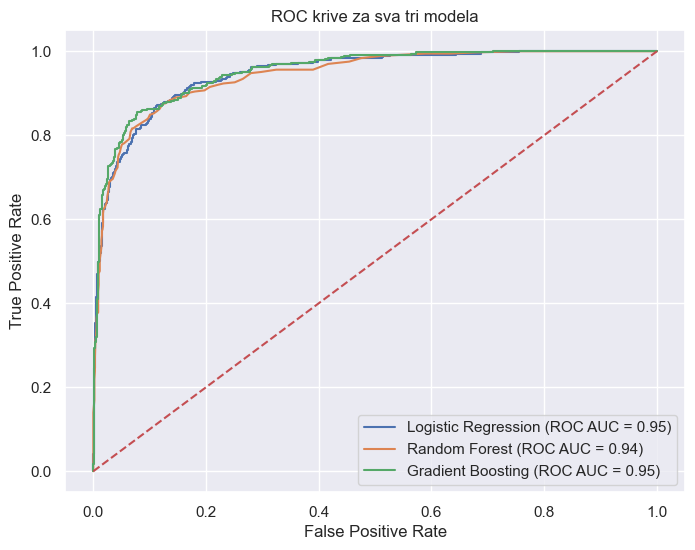

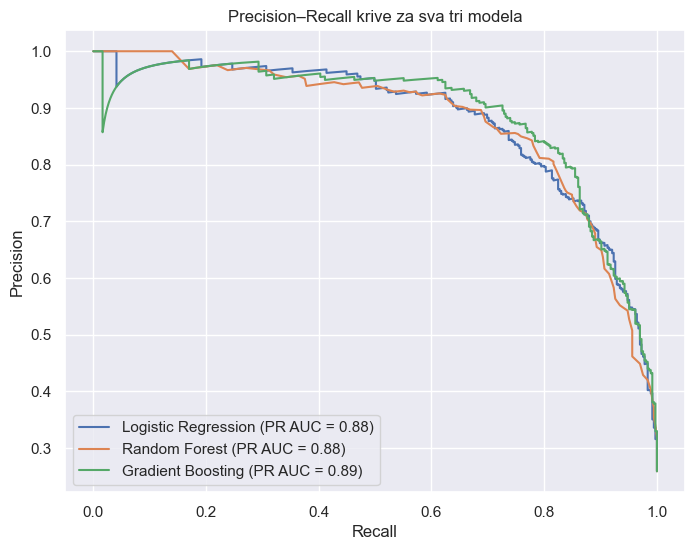


--- Logistic Regression ---
Train F1-score: 0.787
Test F1-score:  0.790

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1044
           1       0.81      0.77      0.79       365

    accuracy                           0.89      1409
   macro avg       0.87      0.85      0.86      1409
weighted avg       0.89      0.89      0.89      1409



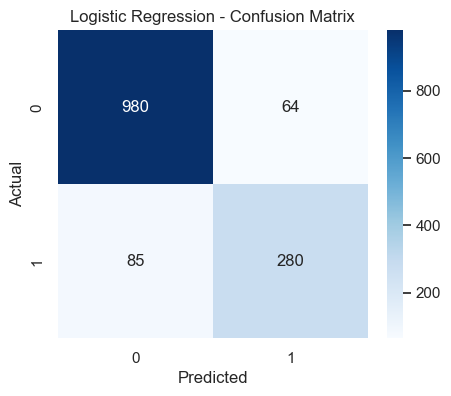


--- Random Forest ---
Train F1-score: 1.000
Test F1-score:  0.802

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      1044
           1       0.85      0.76      0.80       365

    accuracy                           0.90      1409
   macro avg       0.88      0.86      0.87      1409
weighted avg       0.90      0.90      0.90      1409



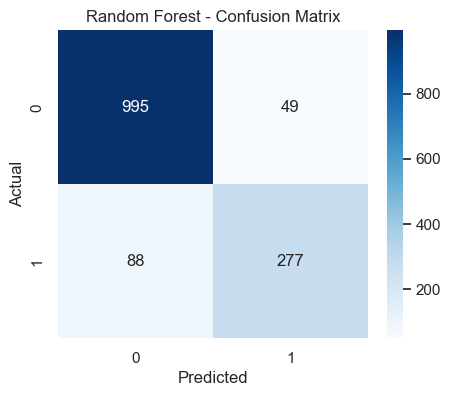

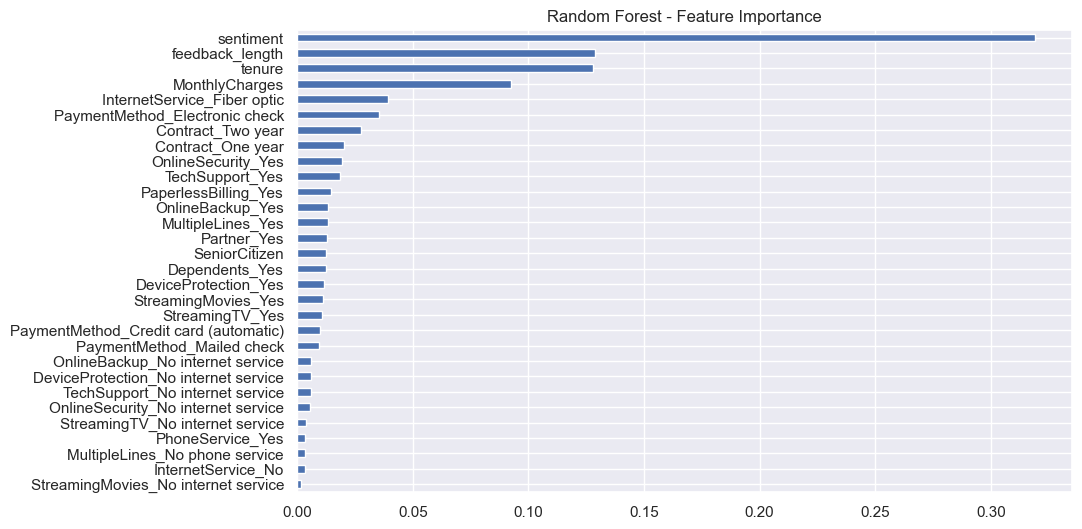


--- Gradient Boosting ---
Train F1-score: 0.826
Test F1-score:  0.815

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1044
           1       0.85      0.78      0.81       365

    accuracy                           0.91      1409
   macro avg       0.89      0.87      0.88      1409
weighted avg       0.91      0.91      0.91      1409



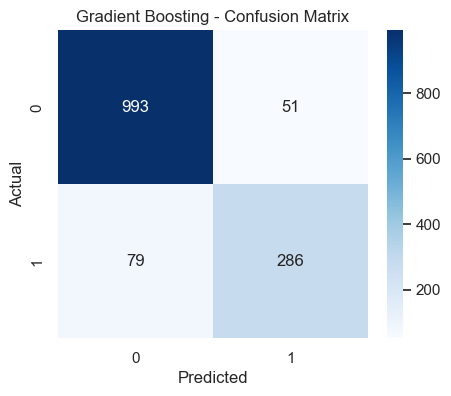

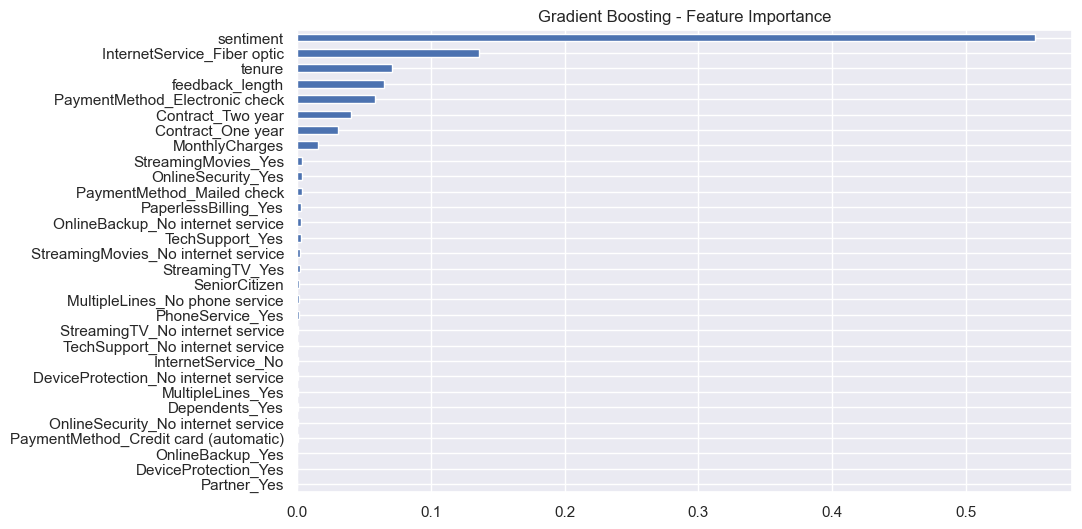


Test F1-score Summary:
Logistic Regression: 0.790
Random Forest: 0.802
Gradient Boosting: 0.815


In [32]:
# ---- Importi ----
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns


# ---- Dataset ----

# ---- TRAIN ----
input_train = train_scaled.drop(["ChurnBinary", "CustomerFeedback"], axis=1)
output_train = train_scaled["ChurnBinary"]

# ---- TEST ----
input_test = test_scaled.drop(["ChurnBinary", "CustomerFeedback"], axis=1)
output_test = test_scaled["ChurnBinary"]


# ---- Lista modela ----
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}


# ============================================================
# ✅ ROC krive za sva tri modela (jedan grafikon)
# ============================================================

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(input_train, output_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(input_test)[:, 1]

        fpr, tpr, _ = roc_curve(output_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (ROC AUC = {roc_auc:.2f})")


# baseline dijagonala
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krive za sva tri modela")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ============================================================
# ✅ Precision–Recall krive za sva tri modela (jedan grafikon)
# ============================================================

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(input_train, output_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(input_test)[:, 1]

        precision, recall, _ = precision_recall_curve(output_test, y_prob)

        pr_auc = average_precision_score(output_test, y_prob)

        plt.plot(recall, precision, label=f"{name} (PR AUC = {pr_auc:.2f})")


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall krive za sva tri modela")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# ============================================================
# ✅ Evaluacija svakog modela (F1 + matrica konfuzije)
# ============================================================

results = {}

for name, model in models.items():

    model.fit(input_train, output_train)

    pred_train = model.predict(input_train)
    pred_test = model.predict(input_test)

    # Evaluacija (F1-score umesto Accuracy)
    f1_train = f1_score(output_train, pred_train, pos_label=1)
    f1_test = f1_score(output_test, pred_test, pos_label=1)

    print(f"\n--- {name} ---")
    print(f"Train F1-score: {f1_train:.3f}")
    print(f"Test F1-score:  {f1_test:.3f}")

    print("\nClassification Report (Test):")
    print(classification_report(output_test, pred_test))

    # Confusion Matrix
    cm = confusion_matrix(output_test, pred_test)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    # Feature importance (samo za RF i GB)
    if name in ["Random Forest", "Gradient Boosting"]:

        importances = pd.Series(model.feature_importances_,
                                index=input_train.columns)

        importances.sort_values().plot(kind="barh", figsize=(10,6))
        plt.title(f"{name} - Feature Importance")
        plt.show()

    results[name] = f1_test


# ---- Rezime ----
print("\n==============================")
print("Test F1-score Summary:")
print("==============================")

for name, score in results.items():
    print(f"{name}: {score:.3f}")


In [33]:
!pip install sentence-transformers


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
#!pip install sentence_transformers
import certifi
import os

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

In [35]:
import certifi
import os

os.environ["SSL_CERT_FILE"] = certifi.where()

In [36]:
import ssl
print(ssl.get_default_verify_paths())

DefaultVerifyPaths(cafile='c:\\Users\\ttrkulja\\Desktop\\Teodora\\Master rad 2\\Main code2\\venv\\Lib\\site-packages\\certifi\\cacert.pem', capath=None, openssl_cafile_env='SSL_CERT_FILE', openssl_cafile='C:\\Program Files\\Common Files\\SSL/cert.pem', openssl_capath_env='SSL_CERT_DIR', openssl_capath='C:\\Program Files\\Common Files\\SSL/certs')


In [37]:
import ssl
print(ssl.OPENSSL_VERSION)

OpenSSL 3.0.13 30 Jan 2024


In [40]:
import json

pooling_config = {
  "word_embedding_dimension": 384,
  "pooling_mode_cls_token": False,
  "pooling_mode_mean_tokens": True,
  "pooling_mode_max_tokens": False,
  "pooling_mode_mean_sqrt_len_tokens": False
}

with open("./hf_models/st_model/1_Pooling/config.json", "w") as f:
    json.dump(pooling_config, f, indent=2)

print("Fajl uspješno zamijenjen.")

Fajl uspješno zamijenjen.


In [52]:
print("safe_cols:", safe_cols)
print("X_train columns:", X_train.columns.tolist())

safe_cols: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
X_train columns: ['emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'em

InternetService_Fiber optic              0.307803
PaymentMethod_Electronic check           0.295807
MonthlyCharges                           0.200558
PaperlessBilling_Yes                     0.190000
SeniorCitizen                            0.157142
StreamingTV_Yes                          0.079496
StreamingMovies_Yes                      0.063325
MultipleLines_Yes                        0.044814
PhoneService_Yes                         0.009757
MultipleLines_No phone service          -0.009757
DeviceProtection_Yes                    -0.053885
OnlineBackup_Yes                        -0.071702
PaymentMethod_Mailed check              -0.089456
PaymentMethod_Credit card (automatic)   -0.133314
Partner_Yes                             -0.144499
TechSupport_Yes                         -0.162342
OnlineSecurity_Yes                      -0.166087
Dependents_Yes                          -0.168093
Contract_One year                       -0.176202
InternetService_No                      -0.233047


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6788.61it/s]
BertModel LOAD REPORT from: ./hf_models/st_model
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 45/45 [00:24<00:00,  1.84it/s]


Shape X_train: (5634, 412)
Shape X_test: (1409, 412)


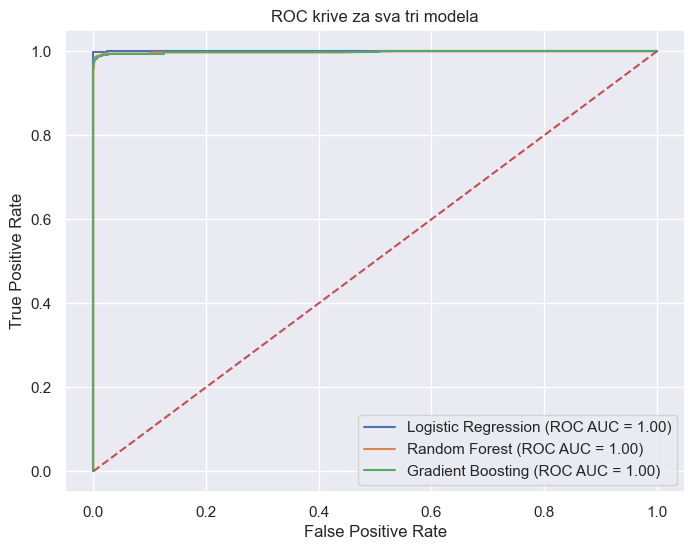

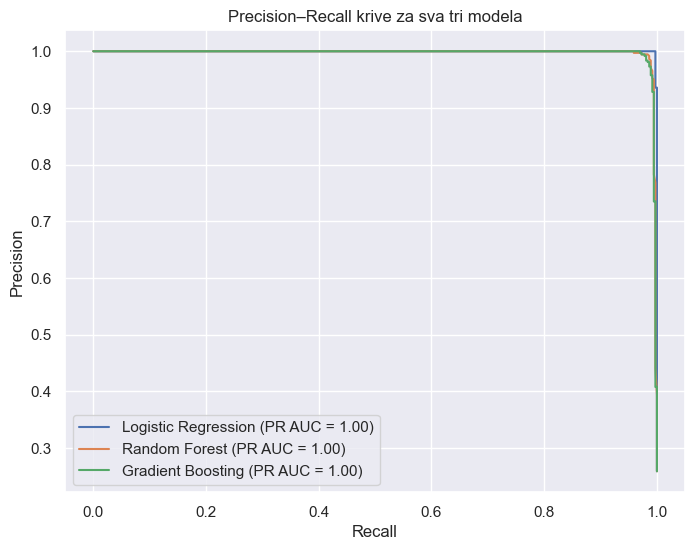


--- Logistic Regression ---
Train F1-score: 1.000
Test F1-score:  0.999

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1044
           1       1.00      1.00      1.00       365

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409



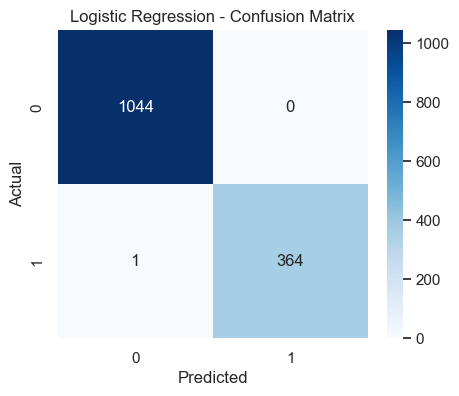


--- Random Forest ---
Train F1-score: 1.000
Test F1-score:  0.985

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1044
           1       1.00      0.97      0.98       365

    accuracy                           0.99      1409
   macro avg       0.99      0.99      0.99      1409
weighted avg       0.99      0.99      0.99      1409



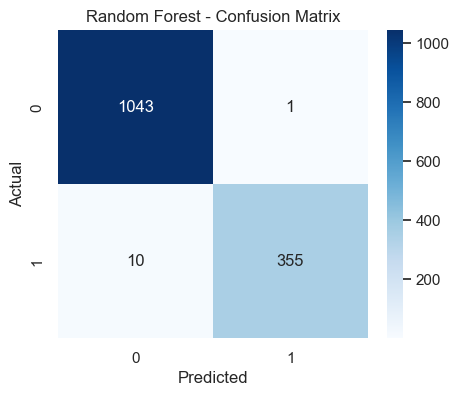

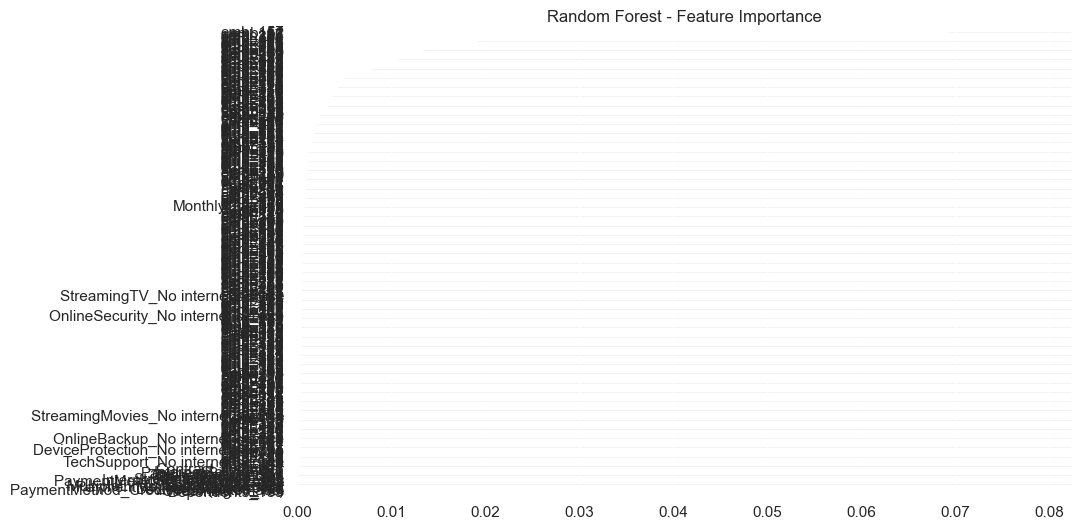


--- Gradient Boosting ---
Train F1-score: 1.000
Test F1-score:  0.985

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1044
           1       0.99      0.98      0.98       365

    accuracy                           0.99      1409
   macro avg       0.99      0.99      0.99      1409
weighted avg       0.99      0.99      0.99      1409



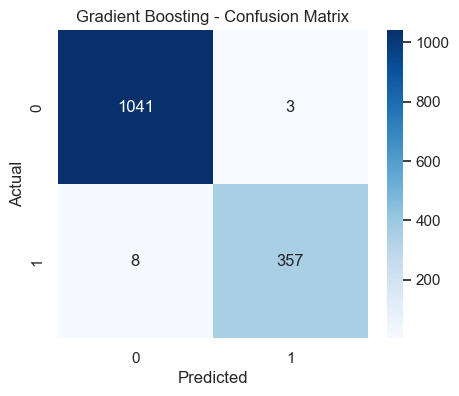

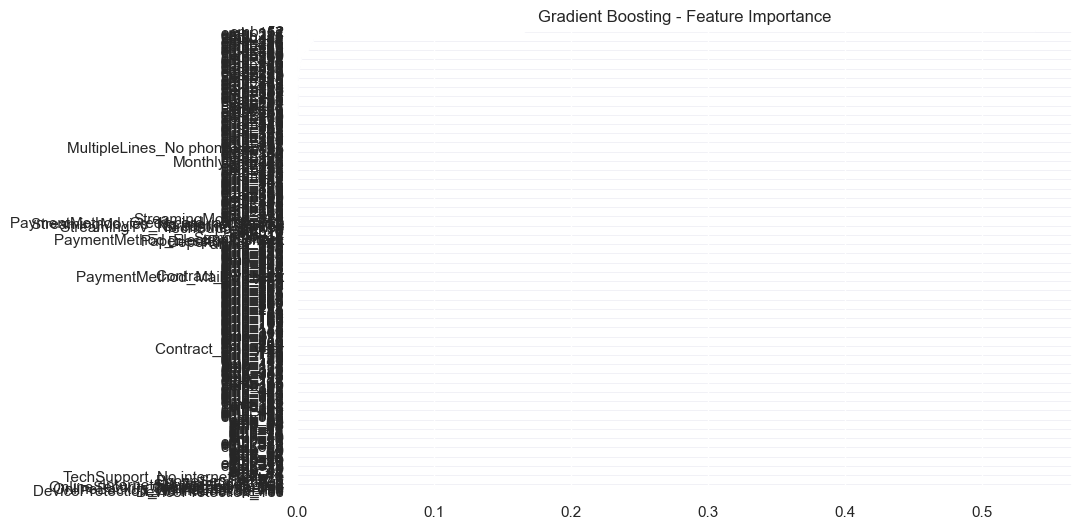


Test F1-score Summary:
Logistic Regression: 0.999
Random Forest: 0.985
Gradient Boosting: 0.985


In [ ]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer


# =========================
# 2. PROVERA MODELA
# =========================
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"

from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "./hf_models/st_model"
)


# =========================
# 3. FEATURE / LABEL SPLIT
# =========================
input_text_train = train_scaled["CustomerFeedback"].astype(str)
input_text_test = test_scaled["CustomerFeedback"].astype(str)

y_train = train_scaled["ChurnBinary"]
y_test = test_scaled["ChurnBinary"]

# =========================
# 4. EMBEDDINGS
# =========================
train_embeddings = model.encode(
    input_text_train.tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

test_embeddings = model.encode(
    input_text_test.tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)


# =========================
# 5. SCALING
# =========================
scaler = StandardScaler()

train_embeddings_scaled = scaler.fit_transform(train_embeddings)
test_embeddings_scaled = scaler.transform(test_embeddings)


# =========================
# 6. DATAFRAME OD EMBEDDINGS
# =========================
train_emb_df = pd.DataFrame(
    train_embeddings_scaled,
    columns=[f"emb_{i}" for i in range(train_embeddings_scaled.shape[1])]
)

test_emb_df = pd.DataFrame(
    test_embeddings_scaled,
    columns=[f"emb_{i}" for i in range(test_embeddings_scaled.shape[1])]
)


# =========================
# 7. CLEAN FEATURE SELECTION
# =========================
drop_cols = ["CustomerFeedback", "feedback_length", "sentiment","ChurnBinary"]

safe_cols = [col for col in train_scaled.columns if col not in drop_cols]


# =========================
# 8. FINAL X MATRICE
# =========================
X_train = pd.concat([
    train_emb_df.reset_index(drop=True),
    train_scaled[safe_cols].reset_index(drop=True)
], axis=1)

X_test = pd.concat([
    test_emb_df.reset_index(drop=True),
    test_scaled[safe_cols].reset_index(drop=True)
], axis=1)


print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)






# ---- Importi ----
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns


# ---- Dataset ----
input_train = X_train   
output_train = y_train.reset_index(drop=True)

input_test = X_test
output_test = y_test.reset_index(drop=True)

# ---- Lista modela ----
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
}


# ============================================================
# ✅ ROC krive za sva tri modela (jedan grafikon)
# ============================================================

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(input_train, output_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(input_test)[:, 1]

        fpr, tpr, _ = roc_curve(output_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{name} (ROC AUC = {roc_auc:.2f})")


# baseline dijagonala
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krive za sva tri modela")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# ============================================================
# ✅ Precision–Recall krive za sva tri modela (jedan grafikon)
# ============================================================

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(input_train, output_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(input_test)[:, 1]

        precision, recall, _ = precision_recall_curve(output_test, y_prob)

        pr_auc = average_precision_score(output_test, y_prob)

        plt.plot(recall, precision, label=f"{name} (PR AUC = {pr_auc:.2f})")


plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall krive za sva tri modela")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


# ============================================================
# ✅ Evaluacija svakog modela (F1 + matrica konfuzije)
# ============================================================

results = {}

for name, model in models.items():

    model.fit(input_train, output_train)

    pred_train = model.predict(input_train)
    pred_test = model.predict(input_test)

    # Evaluacija (F1-score umesto Accuracy)
    f1_train = f1_score(output_train, pred_train, pos_label=1)
    f1_test = f1_score(output_test, pred_test, pos_label=1)

    print(f"\n--- {name} ---")
    print(f"Train F1-score: {f1_train:.3f}")
    print(f"Test F1-score:  {f1_test:.3f}")

    print("\nClassification Report (Test):")
    print(classification_report(output_test, pred_test))

    # Confusion Matrix
    cm = confusion_matrix(output_test, pred_test)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    # Feature importance (samo za RF i GB)
    if name in ["Random Forest", "Gradient Boosting"]:

        importances = pd.Series(model.feature_importances_,
                                index=input_train.columns)

        importances.sort_values().plot(kind="barh", figsize=(10,6))
        plt.title(f"{name} - Feature Importance")
        plt.show()

    results[name] = f1_test


# ---- Rezime ----
print("\n==============================")
print("Test F1-score Summary:")
print("==============================")

for name, score in results.items():
    print(f"{name}: {score:.3f}")


In [49]:
X_test.head()

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.241332,-0.239879,0.412654,-0.010008,1.222532,-3.202044,-1.298112,-1.176741,0.327461,-0.797651,...,False,False,False,False,False,False,True,False,True,False
1,0.879974,-1.289154,0.469525,0.041924,0.814047,-0.995265,0.165515,-0.197665,0.068480,0.341254,...,False,True,False,False,False,False,True,False,True,False
2,-0.822679,0.106394,0.438087,1.776940,-0.756305,-1.041771,-0.048349,1.729633,0.408498,-0.266401,...,False,True,False,True,False,False,True,False,False,True
3,-0.972572,0.965876,-1.297489,-1.864672,0.069473,2.548013,0.200879,1.000873,0.762525,-0.417927,...,True,False,True,False,False,True,False,True,False,False
4,-1.038524,0.587285,0.879135,-0.512413,-1.805506,-1.110354,-0.277419,1.180537,-0.396956,-0.777046,...,False,False,False,False,False,True,False,False,False,False
